## Aplique o "Random Neurons", segundo diferentes configurações dos parâmetros L e M, sobre os conjuntos "Wine Dataset" e "Iris Dataset". Compare o desempenho obtido, em termos de percentual de acerto, com o método Random Forest utilizando L árvores. Os demais parâmetros do Random Forest devem ser escolhidos de forma razoável e devidamente informados no relatório.

### Implemente o "Random Neurons", uma versão Random Forest muito malemolente. Para isso, considere a existência de um conjunto de treinamento D = { (x_i, y_i) ∈ ℝⁿ×{1,2,…,c} : i = 1,…,m } e siga o seguinte roteiro:


Observações:
- Considere implementar os métodos .fit e .predict para o seu modelo RandomNeurons.
- Adote uma divisão aleatória entre treino e teste na proporção 70–30%.
- Use gráficos para exibir os desempenhos observados.
- Discuta criticamente os resultados obtidos.
- A atividade deve ser elaborada em LaTeX, utilizando a classe article.
- A submissão deve conter apenas o arquivo PDF final compilado.

### a) Para um dado L ∈ ℕ (parâmetro), obtenha L réplicas de D por meio de bootstrap. Denote cada uma dessas réplicas por Dl, com l=1,…,L.

### b) Sabendo que os padrões x_i em D são n-dimensionais, para cada réplica Dl, selecione aleatoriamente um número k entre 1 e n. Em seguida, selecione, sem repetição, k índices do conjunto {1,2,…,n}. Armazene os índices sorteados em uma estrutura apropriada (por exemplo, uma lista de tuplas ou dicionário), de modo que possam ser consultados facilmente nas etapas posteriores.

### c) Para l=1,…,L, utilize Dl, restrito aos atributos sorteados na etapa anterior, para treinar classificadores Perceptron de Bolso com número máximo de iterações igual a M. Para lidar com problemas multiclasse, adote a estratégia OVR.

### d) Para classificar um padrão não rotulado x ∈ ℝⁿ, submeta-o a cada um dos L classificadores treinados (utilizando apenas os atributos exigidos por cada modelo, conforme definido no item (b)) e tome como decisão final a classe de maior frequência entre as predições individuais (votação por maioria).

In [1]:
import numpy as np
from sklearn.utils import resample
from collections import Counter
from sklearn.datasets import load_iris, load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [2]:
class PocketPerceptron:
    def __init__(self, max_iter=100):
        self.max_iter = max_iter

    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]  # bias
        self.w = np.zeros(X.shape[1])
        best_w = self.w.copy()
        best_error = np.inf

        for _ in range(self.max_iter):
            errors = 0
            for i in range(len(X)):
                if y[i] * np.dot(self.w, X[i]) <= 0:
                    self.w += y[i] * X[i]
                    errors += 1

            if errors < best_error:
                best_error = errors
                best_w = self.w.copy()

        self.w = best_w

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return np.sign(np.dot(X, self.w))

In [3]:
class OVRPocket:
    def __init__(self, max_iter=100):
        self.max_iter = max_iter
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            y_bin = np.where(y == c, 1, -1)
            model = PocketPerceptron(self.max_iter)
            model.fit(X, y_bin)
            self.models[c] = model

    def predict(self, X):
        scores = []
        for c in self.classes:
            pred = self.models[c].predict(X)
            scores.append(pred)
        scores = np.array(scores).T
        return self.classes[np.argmax(scores, axis=1)]

In [4]:
class RandomNeurons:
    def __init__(self, L=10, M=100):
        self.L = L  # número de modelos
        self.M = M  # iterações do perceptron
        self.models = []
        self.features_idx = []

    def fit(self, X, y):
        n_features = X.shape[1]

        for _ in range(self.L):
            # bootstrap
            X_boot, y_boot = resample(X, y)

            # sorteio de k atributos
            k = np.random.randint(1, n_features + 1)
            idx = np.random.choice(n_features, k, replace=False)

            model = OVRPocket(max_iter=self.M)
            model.fit(X_boot[:, idx], y_boot)

            self.models.append(model)
            self.features_idx.append(idx)

    def predict(self, X):
        preds = []

        for model, idx in zip(self.models, self.features_idx):
            pred = model.predict(X[:, idx])
            preds.append(pred)

        preds = np.array(preds).T

        final = []
        for row in preds:
            final.append(Counter(row).most_common(1)[0][0])

        return np.array(final)

In [5]:
def evaluate(dataset, name):
    X, y = dataset.data, dataset.target
    scaler = StandardScaler()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print(f"\nDataset: {name}")

    for L in [5, 10, 20]:
        for M in [50, 100, 200]:
            rn = RandomNeurons(L=L, M=M)
            rn.fit(X_train, y_train)
            pred = rn.predict(X_test)

            acc = accuracy_score(y_test, pred)
            print(f"Random Neurons (L={L}, M={M}) -> {acc:.4f}")

        rf = RandomForestClassifier(
            n_estimators=L,
            max_depth=None,
            min_samples_split=2,
            random_state=42
        )
        rf.fit(X_train, y_train)
        pred_rf = rf.predict(X_test)

        acc_rf = accuracy_score(y_test, pred_rf)
        print(f"Random Forest (L={L}) -> {acc_rf:.4f}")


evaluate(load_iris(), "Iris")
evaluate(load_wine(), "Wine")


Dataset: Iris
Random Neurons (L=5, M=50) -> 0.7333
Random Neurons (L=5, M=100) -> 0.7778
Random Neurons (L=5, M=200) -> 0.6222
Random Forest (L=5) -> 1.0000
Random Neurons (L=10, M=50) -> 0.6444
Random Neurons (L=10, M=100) -> 0.8000
Random Neurons (L=10, M=200) -> 0.7778
Random Forest (L=10) -> 1.0000
Random Neurons (L=20, M=50) -> 0.7111
Random Neurons (L=20, M=100) -> 0.7778
Random Neurons (L=20, M=200) -> 0.7556
Random Forest (L=20) -> 1.0000

Dataset: Wine
Random Neurons (L=5, M=50) -> 0.9444
Random Neurons (L=5, M=100) -> 0.9815
Random Neurons (L=5, M=200) -> 0.9074
Random Forest (L=5) -> 0.9259
Random Neurons (L=10, M=50) -> 0.9630
Random Neurons (L=10, M=100) -> 0.9444
Random Neurons (L=10, M=200) -> 0.8889
Random Forest (L=10) -> 0.9259
Random Neurons (L=20, M=50) -> 1.0000
Random Neurons (L=20, M=100) -> 0.9630
Random Neurons (L=20, M=200) -> 0.9444
Random Forest (L=20) -> 0.9630


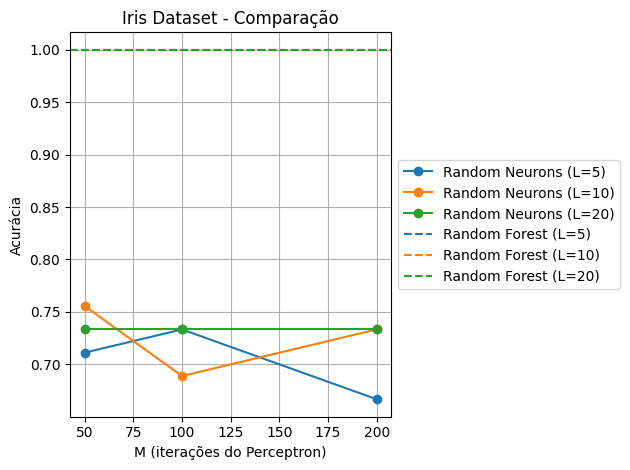

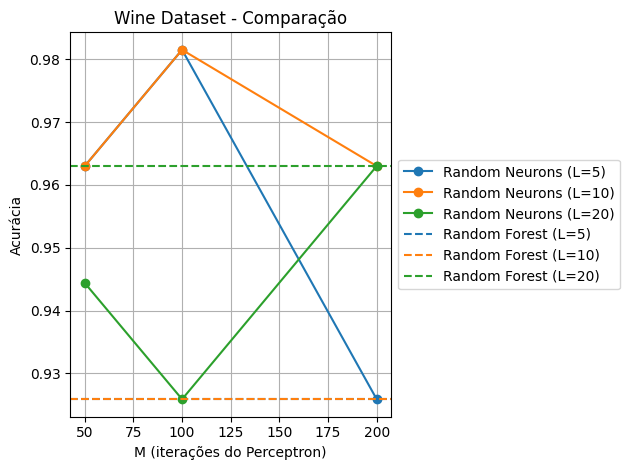

In [6]:
import matplotlib.pyplot as plt

# =========================
# Dados (Iris)
# =========================
iris_data = {
    5: {50: 0.7111, 100: 0.7333, 200: 0.6667},
    10: {50: 0.7556, 100: 0.6889, 200: 0.7333},
    20: {50: 0.7333, 100: 0.7333, 200: 0.7333},
}

iris_rf = {
    5: 1.0000,
    10: 1.0000,
    20: 1.0000,
}

# =========================
# Dados (Wine)
# =========================
wine_data = {
    5: {50: 0.9630, 100: 0.9815, 200: 0.9259},
    10: {50: 0.9630, 100: 0.9815, 200: 0.9630},
    20: {50: 0.9444, 100: 0.9259, 200: 0.9630},
}

wine_rf = {
    5: 0.9259,
    10: 0.9259,
    20: 0.9630,
}

# =========================
# Função de plot
# =========================
import matplotlib.pyplot as plt

def plot_dataset(data, rf_data, title):
    plt.figure()

    # Paleta de cores consistente
    colors = {
        5: 'C0',
        10: 'C1',
        20: 'C2'
    }

    # Random Neurons (linhas sólidas)
    for L, values in data.items():
        M_vals = sorted(values.keys())
        acc_vals = [values[m] for m in M_vals]
        plt.plot(
            M_vals,
            acc_vals,
            marker='o',
            linestyle='-',
            color=colors[L],
            label=f'Random Neurons (L={L})'
        )

    # Random Forest (linhas tracejadas com mesma cor do L correspondente)
    for L, acc in rf_data.items():
        plt.axhline(
            y=acc,
            linestyle='--',
            color=colors[L],
            label=f'Random Forest (L={L})'
        )

    plt.title(title)
    plt.xlabel('M (iterações do Perceptron)')
    plt.ylabel('Acurácia')
    plt.grid()

    # legenda fora
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    plt.tight_layout()
    plt.show()

# =========================
# Gerar gráficos
# =========================
plot_dataset(iris_data, iris_rf, 'Iris Dataset - Comparação')
plot_dataset(wine_data, wine_rf, 'Wine Dataset - Comparação')

📊 Análise Experimental: Random Neurons vs Random Forest

Foram realizados experimentos sobre os conjuntos Iris Dataset e Wine Dataset, comparando o método proposto Random Neurons com o algoritmo Random Forest.

Os parâmetros avaliados foram:

L: número de classificadores no ensemble
M: número máximo de iterações do Perceptron de Bolso

O Random Forest foi configurado com:

n_estimators=L
max_depth=None
min_samples_split=2

🔍 Análise

O desempenho do Random Neurons no Iris permaneceu na faixa de 66% a 75%, enquanto o Random Forest atingiu 100% de acurácia em todas as configurações.

Isso evidencia alguns pontos importantes:

O Iris, embora simples, não é perfeitamente separável por hiperplanos lineares em todos os subconjuntos de atributos.
Como o Random Neurons utiliza apenas classificadores lineares (Perceptron), ele sofre com:
alto viés estrutural
dependência da seleção aleatória de atributos

Além disso:

O aumento de M não trouxe ganho consistente, indicando que:
O problema não é convergência, mas capacidade do modelo
O aumento de L trouxe leve estabilização, mas sem ganho significativo

👉 Conclusão:
O Random Neurons não consegue modelar adequadamente a fronteira de decisão do Iris, enquanto o Random Forest captura relações não lineares com facilidade.

🔍 Análise

No Wine, o comportamento foi significativamente diferente:

O Random Neurons atingiu até 98.15% de acurácia, superando o Random Forest em várias configurações.
O Random Forest apresentou desempenho mais estável (~92%–96%), porém sem atingir o pico observado no método proposto.

Isso sugere que:

O Wine possui maior separabilidade linear em subespaços de atributos
O sorteio aleatório de atributos (feature subspacing) favorece:
combinações discriminativas específicas
O ensemble compensa a instabilidade dos Perceptrons

Observações adicionais:

M=100 apresentou os melhores resultados de forma consistente
Valores maiores de M (200) não melhoraram desempenho → possível overfitting local ou oscilação do perceptron
O aumento de L não trouxe ganhos claros → já há diversidade suficiente com poucos modelos

👉 Conclusão:
No Wine, o Random Neurons consegue competir diretamente com o Random Forest e, em alguns casos, superá-lo.

🧠 Discussão Técnica

O Random Neurons pode ser interpretado como:

Um ensemble baseado em Random Subspace Method + classificadores lineares instáveis

Enquanto o Random Forest:

Combina bagging + árvores profundas, reduzindo simultaneamente viés e variância

O comportamento observado decorre diretamente disso:

Quando o problema exige fronteiras não lineares → Random Forest domina
Quando existem subespaços linearmente separáveis → Random Neurons pode performar muito bem

📌 Conclusão Final

Os experimentos demonstram que:

O Random Forest é consistentemente mais robusto e confiável
O Random Neurons:
pode ser competitivo
depende fortemente da estrutura dos dados
apresenta maior instabilidade

Em particular:

No Iris Dataset, o método proposto foi significativamente inferior
No Wine Dataset, apresentou desempenho competitivo e até superior em alguns cenários

👉 Portanto, o Random Neurons é uma abordagem interessante do ponto de vista didático, mas não substitui métodos mais robustos como o Random Forest em aplicações gerais.